
📊 Model Evaluation for FP_D_Count:
Mean Absolute Error (MAE): 0.39
Root Mean Squared Error (RMSE): 0.58
R² Score: 0.65


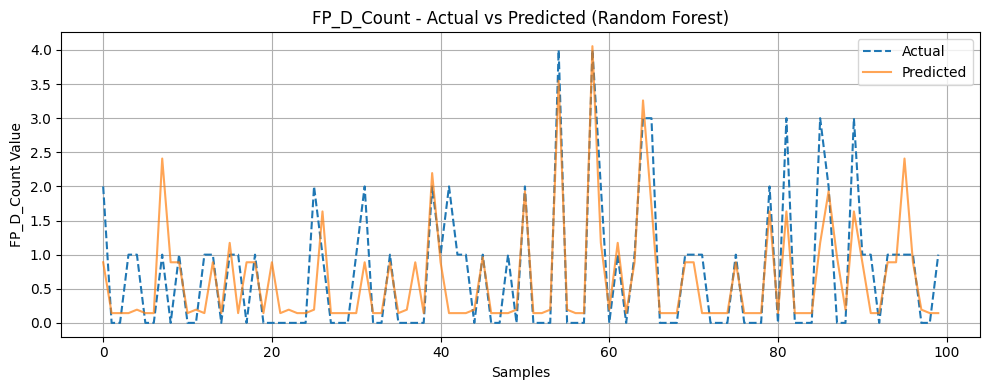

In [ ]:
#Regular (only FP_D_Count) - 100 trees.


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load the data
file_path = "junction_data_race_course (1).csv"
df = pd.read_csv(file_path)

# Function to create lagged features for FP_D_Count only
def create_lagged_features_for_fpd(data, lag=2):
    if "FP_D_Count" not in data.columns:
        raise ValueError("FP_D_Count column not found in the dataset.")

    lagged = data[["FP_D_Count"]].copy()
    for l in range(1, lag + 1):
        lagged[f"FP_D_Count_lag{l}"] = data["FP_D_Count"].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)

    feature_cols = [col for col in lagged.columns if "lag" in col]
    X = lagged[feature_cols]
    y = lagged["FP_D_Count"]
    return X, y

# Function to run model and plot predictions
def run_rf_for_fpd(df, lag=2):
    X, y = create_lagged_features_for_fpd(df, lag=lag)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Random Forest
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Model Evaluation for FP_D_Count:")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("FP_D_Count - Actual vs Predicted (Random Forest)")
    plt.xlabel("Samples")
    plt.ylabel("FP_D_Count Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run the model for FP_D_Count with lag
lag_value = 2
run_rf_for_fpd(df, lag=lag_value)



📊 Model Evaluation for FP_D_Count (5-min resolution):
Mean Absolute Error (MAE): 0.07
Root Mean Squared Error (RMSE): 0.09
R² Score: 0.96


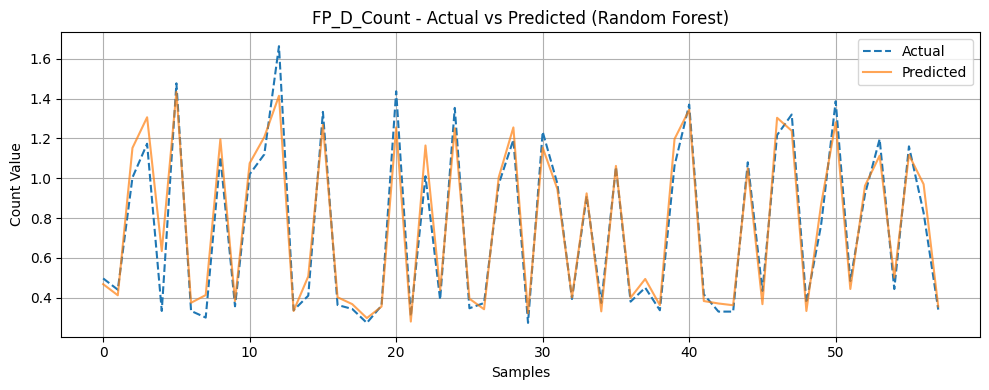

In [ ]:
#Downsampled to per 5 minutes, 200 trees, 15 depth.



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

# Load the data
file_path = "junction_data_race_course (1).csv"
df = pd.read_csv(file_path)

# ---------------- STEP 1: DOWNSAMPLE ----------------
# Downsample to 5-minute intervals (every 300 seconds)
df_downsampled = df.groupby(np.arange(len(df)) // 300).mean(numeric_only=True).reset_index(drop=True)

# ---------------- STEP 2: LAG FEATURES WITH COSINE ----------------
def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    if target_col not in data.columns:
        raise ValueError(f"{target_col} column not found in the dataset.")

    # Use all numeric columns
    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()

    lagged = data[relevant_cols].copy()

    # Add lag features
    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    # Drop NaNs due to shifting
    lagged = lagged.dropna().reset_index(drop=True)

    # Cosine similarity on lagged features only
    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged_features = lagged[lag_cols]

    # Compute cosine similarity between each lagged vector and all others (self-similarity matrix)
    cos_sim_matrix = cosine_similarity(lagged_features)

    # For simplicity, use diagonal values (similarity with self = 1.0), but you can also do row-wise means
    lagged['cosine_similarity'] = np.diag(cos_sim_matrix)

    # Prepare X and y
    feature_cols = [col for col in lagged.columns if col != target_col]
    X = lagged[feature_cols]
    y = lagged[target_col]
    return X, y

# ---------------- STEP 3: RANDOM FOREST ----------------
def run_rf_with_advanced_features(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Random Forest with improved params
    model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Model Evaluation for FP_D_Count (5-min resolution):")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot actual vs predicted
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title(f"{target_col} - Actual vs Predicted (Random Forest)")
    plt.xlabel("Samples")
    plt.ylabel("Count Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------- RUN THE FINAL CODE ----------------
lag_value = 2
run_rf_with_advanced_features(df_downsampled, lag=lag_value)



📊 Model Evaluation for FP_D_Count:
Mean Absolute Error (MAE): 0.39
Root Mean Squared Error (RMSE): 0.58
R² Score: 0.65


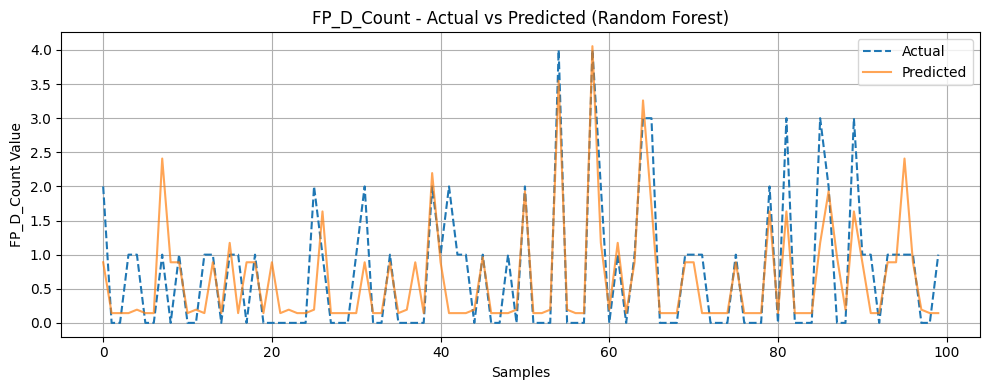

In [ ]:
#Applying lag to all WITHOUT downsampling to per 5 minutes, 100 trees.


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the data
file_path = "junction_data_race_course (1).csv"
df = pd.read_csv(file_path)

# Function to create lagged features for FP_D_Count only
def create_lagged_features_for_fpd(data, lag=2):
    if "FP_D_Count" not in data.columns:
        raise ValueError("FP_D_Count column not found in the dataset.")

    lagged = data[["FP_D_Count"]].copy()
    for l in range(1, lag + 1):
        lagged[f"FP_D_Count_lag{l}"] = data["FP_D_Count"].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)

    feature_cols = [col for col in lagged.columns if "lag" in col]
    X = lagged[feature_cols]
    y = lagged["FP_D_Count"]
    return X, y

# Function to run model and plot predictions
def run_rf_for_fpd(df, lag=2):
    X, y = create_lagged_features_for_fpd(df, lag=lag)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Random Forest
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Model Evaluation for FP_D_Count:")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("FP_D_Count - Actual vs Predicted (Random Forest)")
    plt.xlabel("Samples")
    plt.ylabel("FP_D_Count Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run the model for FP_D_Count with lag
lag_value = 2
run_rf_for_fpd(df, lag=lag_value)



📊 Model Evaluation for FP_D_Count (5-min resolution):
MAE: 0.07
RMSE: 0.09
R² Score: 0.96


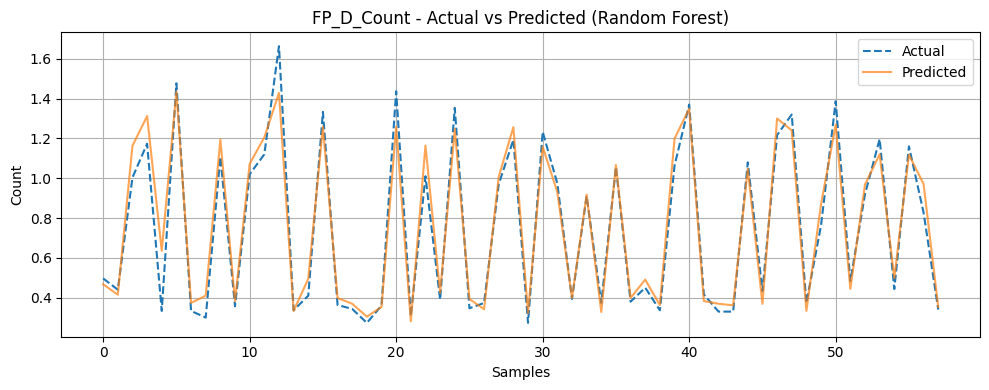

In [ ]:
#Applying lag to all WITH downsampling to per 5 minutes, 200 trees, 15 depth.




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

# ---------------- STEP 1: LOAD & DOWNSAMPLE ----------------
file_path = "junction_data_race_course (1).csv"
df = pd.read_csv(file_path)

# Downsample to 5-minute intervals (every 300 seconds)
df_downsampled = df.groupby(np.arange(len(df)) // 300).mean(numeric_only=True).reset_index(drop=True)

# ---------------- STEP 2: CREATE LAGGED FEATURES + COSINE SIMILARITY ----------------
def create_lagged_features_all(data, target_col="FP_D_Count", lag=2):
    if target_col not in data.columns:
        raise ValueError(f"{target_col} column not found in the dataset.")

    # Get all numeric columns
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

    # Create lagged features
    lagged = pd.DataFrame()
    for col in numeric_cols:
        for l in range(1, lag + 1):
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    # Add current (non-lagged) features
    for col in numeric_cols:
        lagged[col] = data[col]

    # Drop rows with NaNs caused by shifting
    lagged = lagged.dropna().reset_index(drop=True)

    # Calculate cosine similarity from lagged features
    lag_cols = [col for col in lagged.columns if "_lag" in col]
    lagged_features = lagged[lag_cols]
    cos_sim_matrix = cosine_similarity(lagged_features)
    lagged["cosine_similarity"] = np.diag(cos_sim_matrix)

    # Prepare X and y
    X = lagged.drop(columns=[target_col])
    y = lagged[target_col]

    return X, y

# ---------------- STEP 3: RANDOM FOREST REGRESSION ----------------
def run_rf_with_all_lagged_features(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_all(data, target_col=target_col, lag=lag)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train the model
    model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Model Evaluation for FP_D_Count (5-min resolution):")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot predictions
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title(f"{target_col} - Actual vs Predicted (Random Forest)")
    plt.xlabel("Samples")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------- RUN EVERYTHING ----------------
lag_value = 2  # You can change to 5 or 10 to experiment
run_rf_with_all_lagged_features(df_downsampled, lag=lag_value)



📊 15-Minute FP_D_Count Prediction:
MAE: 0.02
RMSE: 0.04
R²: 0.99


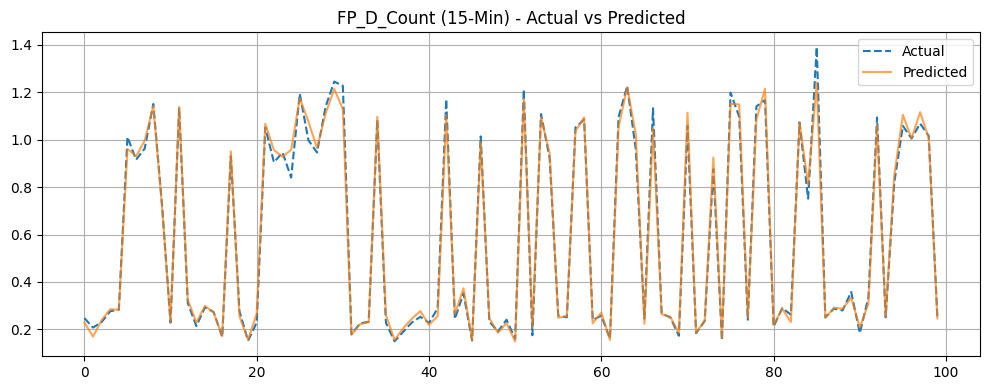

In [ ]:
#15-Minute Prediction (900 seconds), 200 trees, 15 depth.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# 15-minute downsampling
df_downsampled = df.groupby(np.arange(len(df)) // 900).mean(numeric_only=True).reset_index(drop=True)

def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()
    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)
    lagged = lagged.dropna().reset_index(drop=True)
    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged["cosine_similarity"] = np.diag(cosine_similarity(lagged[lag_cols]))
    X = lagged.drop(columns=[target_col])
    y = lagged[target_col]
    return X, y

def run_rf(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\n📊 15-Minute FP_D_Count Prediction:")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"R²: {r2_score(y_test, y_pred):.2f}")
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("FP_D_Count (15-Min) - Actual vs Predicted")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.show()

run_rf(df_downsampled, lag=2)



📊 30-Minute FP_D_Count Prediction:
MAE: 0.02
RMSE: 0.02
R²: 1.00


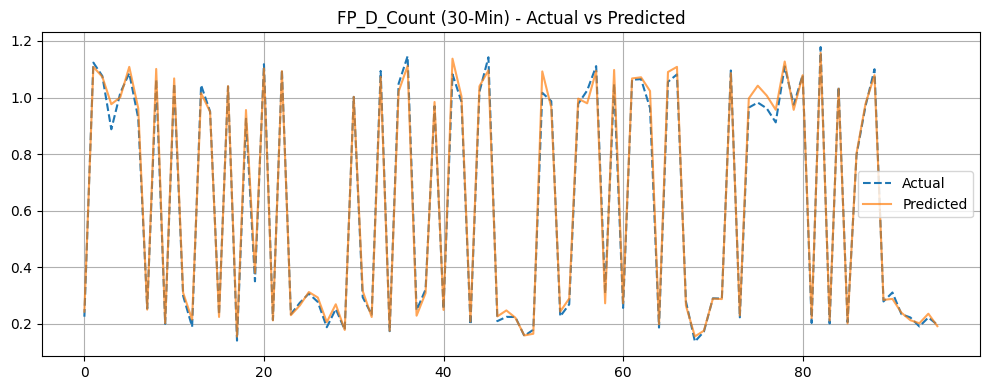

In [ ]:
#30-Minute Prediction (1800 seconds), 200 trees, 15 depth.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# 15-minute downsampling
df_downsampled = df.groupby(np.arange(len(df)) // 1800).mean(numeric_only=True).reset_index(drop=True)

def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()
    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)
    lagged = lagged.dropna().reset_index(drop=True)
    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged["cosine_similarity"] = np.diag(cosine_similarity(lagged[lag_cols]))
    X = lagged.drop(columns=[target_col])
    y = lagged[target_col]
    return X, y

def run_rf(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\n📊 30-Minute FP_D_Count Prediction:")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"R²: {r2_score(y_test, y_pred):.2f}")
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("FP_D_Count (30-Min) - Actual vs Predicted")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.show()

run_rf(df_downsampled, lag=2)



📊 45-Minute FP_D_Count Prediction:
MAE: 0.02
RMSE: 0.02
R²: 1.00


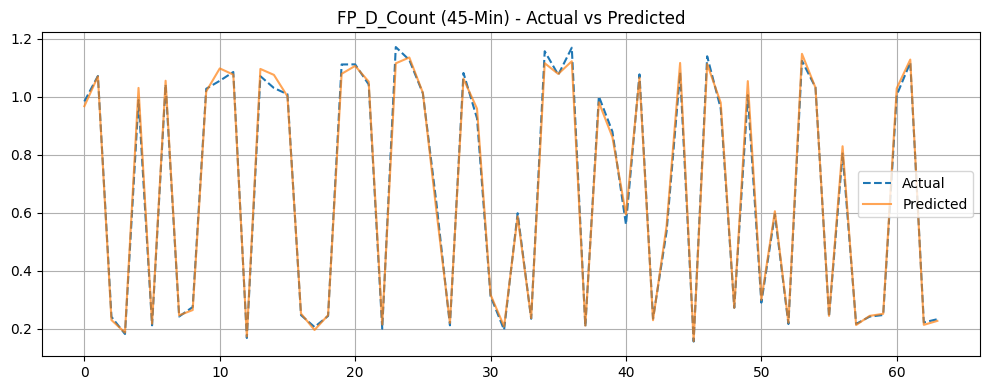

In [ ]:
#45-Minute Prediction (1800 seconds), 200 trees, 15 depth.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# 15-minute downsampling
df_downsampled = df.groupby(np.arange(len(df)) // 2700).mean(numeric_only=True).reset_index(drop=True)

def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()
    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)
    lagged = lagged.dropna().reset_index(drop=True)
    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged["cosine_similarity"] = np.diag(cosine_similarity(lagged[lag_cols]))
    X = lagged.drop(columns=[target_col])
    y = lagged[target_col]
    return X, y

def run_rf(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\n📊 45-Minute FP_D_Count Prediction:")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"R²: {r2_score(y_test, y_pred):.2f}")
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("FP_D_Count (45-Min) - Actual vs Predicted")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.show()

run_rf(df_downsampled, lag=2)



📊 Tuned Random Forest Evaluation (5-min Resolution):
MAE: 0.04
RMSE: 0.06
R² Score: 0.98


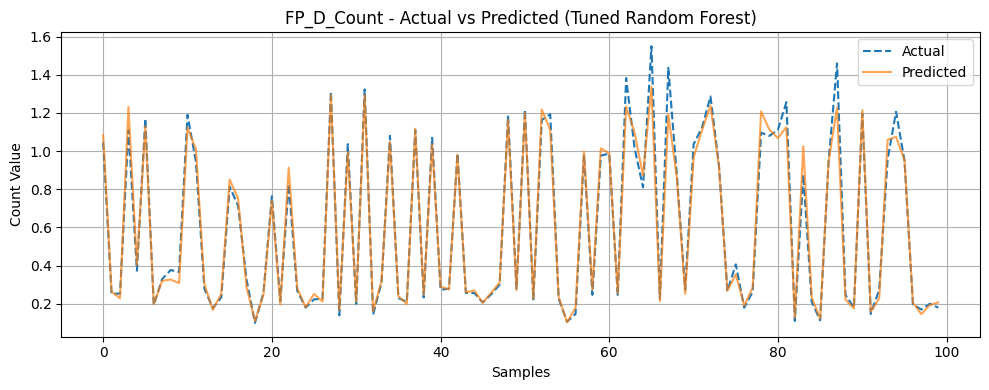

In [ ]:
#Tuning parameters, 300 trees, 25 depth, 5-minute interval.


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

# Load the data
file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# ---------------- STEP 1: DOWNSAMPLE ----------------
# Downsample to 5-minute intervals (every 300 seconds)
df_downsampled = df.groupby(np.arange(len(df)) // 300).mean(numeric_only=True).reset_index(drop=True)

# ---------------- STEP 2: LAG FEATURES WITH COSINE ----------------
def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    if target_col not in data.columns:
        raise ValueError(f"{target_col} column not found in the dataset.")

    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()

    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)

    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged["cosine_similarity"] = np.diag(cosine_similarity(lagged[lag_cols]))

    X = lagged.drop(columns=[target_col])
    y = lagged[target_col]
    return X, y

# ---------------- STEP 3: RANDOM FOREST WITH TUNING ----------------
def run_rf_with_tuned_params(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Tuned parameters
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=25,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Tuned Random Forest Evaluation (5-min Resolution):")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title(f"{target_col} - Actual vs Predicted (Tuned Random Forest)")
    plt.xlabel("Samples")
    plt.ylabel("Count Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------- RUN ----------------
lag_value = 2
run_rf_with_tuned_params(df_downsampled, lag=lag_value)



📊 Tuned Random Forest Evaluation (5-min Resolution):
MAE: 0.04
RMSE: 0.06
R² Score: 0.98


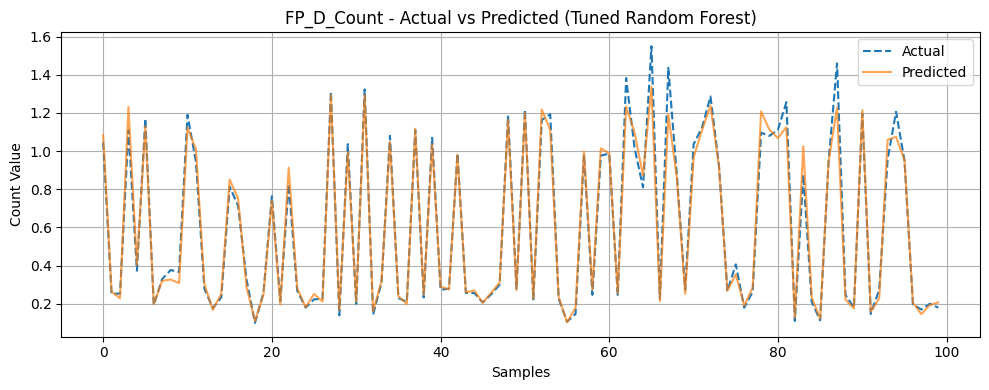

In [ ]:
#Tuning parameters, 300 trees, 30 depth, 5-minute interval


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

# Load the data
file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# ---------------- STEP 1: DOWNSAMPLE ----------------
# Downsample to 5-minute intervals (every 300 seconds)
df_downsampled = df.groupby(np.arange(len(df)) // 300).mean(numeric_only=True).reset_index(drop=True)

# ---------------- STEP 2: LAG FEATURES WITH COSINE ----------------
def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    if target_col not in data.columns:
        raise ValueError(f"{target_col} column not found in the dataset.")

    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()

    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)

    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged["cosine_similarity"] = np.diag(cosine_similarity(lagged[lag_cols]))

    X = lagged.drop(columns=[target_col])
    y = lagged[target_col]
    return X, y

# ---------------- STEP 3: RANDOM FOREST WITH TUNING ----------------
def run_rf_with_tuned_params(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Tuned parameters
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=30,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Tuned Random Forest Evaluation (5-min Resolution):")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title(f"{target_col} - Actual vs Predicted (Tuned Random Forest)")
    plt.xlabel("Samples")
    plt.ylabel("Count Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------- RUN ----------------
lag_value = 2
run_rf_with_tuned_params(df_downsampled, lag=lag_value)



📊 Tuned Random Forest Evaluation (5-min Resolution):
MAE: 0.04
RMSE: 0.06
R² Score: 0.98


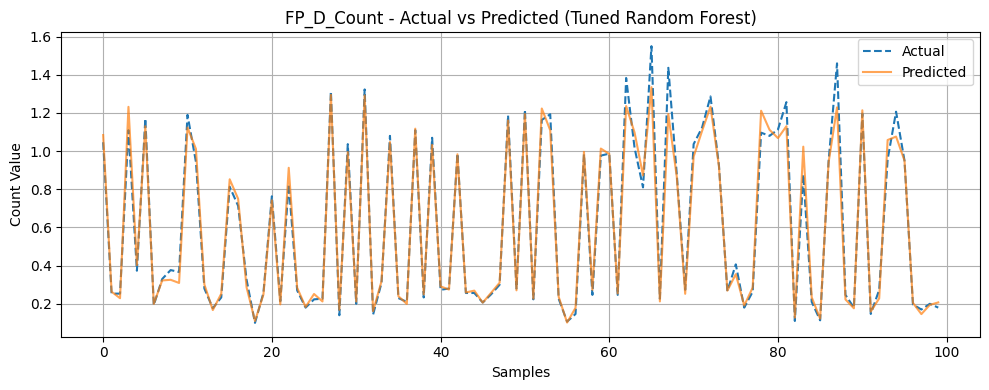

In [ ]:
#Tuning parameters, 250 trees, 25 depth, 5-minute interval.


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

# Load the data
file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# ---------------- STEP 1: DOWNSAMPLE ----------------
# Downsample to 5-minute intervals (every 300 seconds)
df_downsampled = df.groupby(np.arange(len(df)) // 300).mean(numeric_only=True).reset_index(drop=True)

# ---------------- STEP 2: LAG FEATURES WITH COSINE ----------------
def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    if target_col not in data.columns:
        raise ValueError(f"{target_col} column not found in the dataset.")

    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()

    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)

    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged["cosine_similarity"] = np.diag(cosine_similarity(lagged[lag_cols]))

    X = lagged.drop(columns=[target_col])
    y = lagged[target_col]
    return X, y

# ---------------- STEP 3: RANDOM FOREST WITH TUNING ----------------
def run_rf_with_tuned_params(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Tuned parameters
    model = RandomForestRegressor(
        n_estimators=250,
        max_depth=25,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Tuned Random Forest Evaluation (5-min Resolution):")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title(f"{target_col} - Actual vs Predicted (Tuned Random Forest)")
    plt.xlabel("Samples")
    plt.ylabel("Count Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------- RUN ----------------
lag_value = 2
run_rf_with_tuned_params(df_downsampled, lag=lag_value)



📊 Tuned Random Forest Evaluation (5-min Resolution):
MAE: 0.04
RMSE: 0.06
R² Score: 0.98


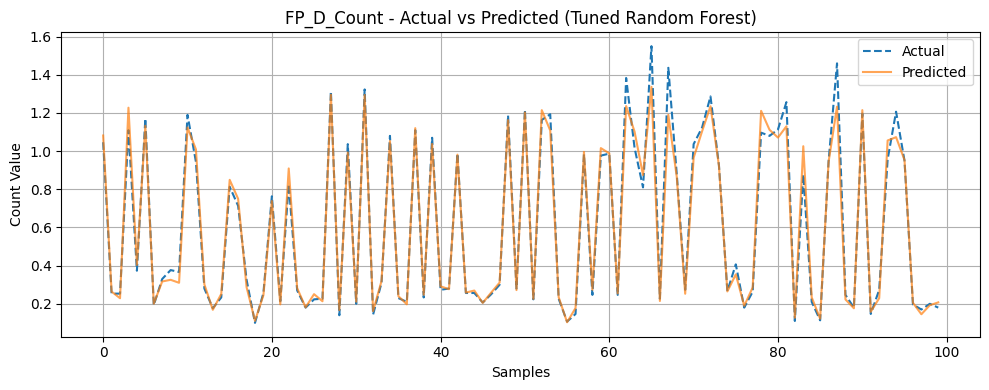

In [ ]:
#Tuning parameters, 600 trees, 30 depth, 5-minute interval.


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

# Load the data
file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# ---------------- STEP 1: DOWNSAMPLE ----------------
# Downsample to 5-minute intervals (every 300 seconds)
df_downsampled = df.groupby(np.arange(len(df)) // 300).mean(numeric_only=True).reset_index(drop=True)

# ---------------- STEP 2: LAG FEATURES WITH COSINE ----------------
def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    if target_col not in data.columns:
        raise ValueError(f"{target_col} column not found in the dataset.")

    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()

    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)

    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged["cosine_similarity"] = np.diag(cosine_similarity(lagged[lag_cols]))

    X = lagged.drop(columns=[target_col])
    y = lagged[target_col]
    return X, y

# ---------------- STEP 3: RANDOM FOREST WITH TUNING ----------------
def run_rf_with_tuned_params(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Tuned parameters
    model = RandomForestRegressor(
        n_estimators=600,
        max_depth=30,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Tuned Random Forest Evaluation (5-min Resolution):")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title(f"{target_col} - Actual vs Predicted (Tuned Random Forest)")
    plt.xlabel("Samples")
    plt.ylabel("Count Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------- RUN ----------------
lag_value = 2
run_rf_with_tuned_params(df_downsampled, lag=lag_value)



📊 45-Minute FP_D_Count Prediction:
MAE: 0.02
RMSE: 0.02
R²: 1.00


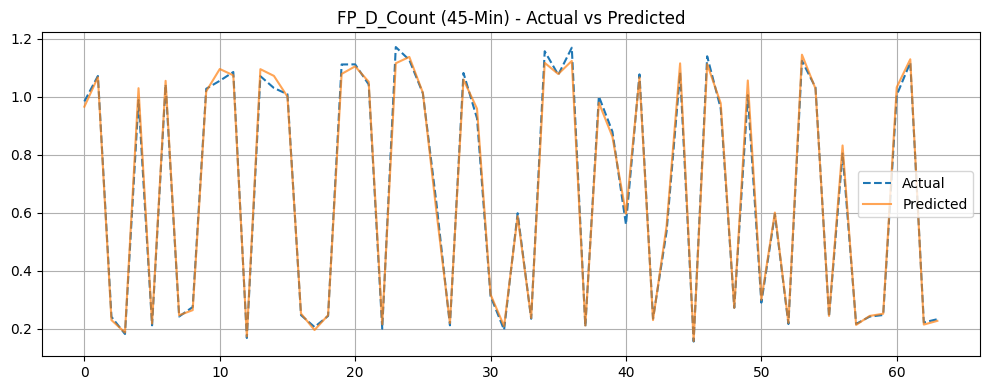

In [ ]:
#Tuning parameters, 300 trees, 25 depth, 45-minute interval.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# 45-minute downsampling
df_downsampled = df.groupby(np.arange(len(df)) // 2700).mean(numeric_only=True).reset_index(drop=True)

def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()
    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)
    lagged = lagged.dropna().reset_index(drop=True)
    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged["cosine_similarity"] = np.diag(cosine_similarity(lagged[lag_cols]))
    X = lagged.drop(columns=[target_col])
    y = lagged[target_col]
    return X, y

def run_rf(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=300, max_depth=25, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\n📊 45-Minute FP_D_Count Prediction:")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"R²: {r2_score(y_test, y_pred):.2f}")
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("FP_D_Count (45-Min) - Actual vs Predicted")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.show()

run_rf(df_downsampled, lag=2)



📊 45-Minute FP_D_Count Prediction:
MAE: 0.02
RMSE: 0.02
R²: 1.00


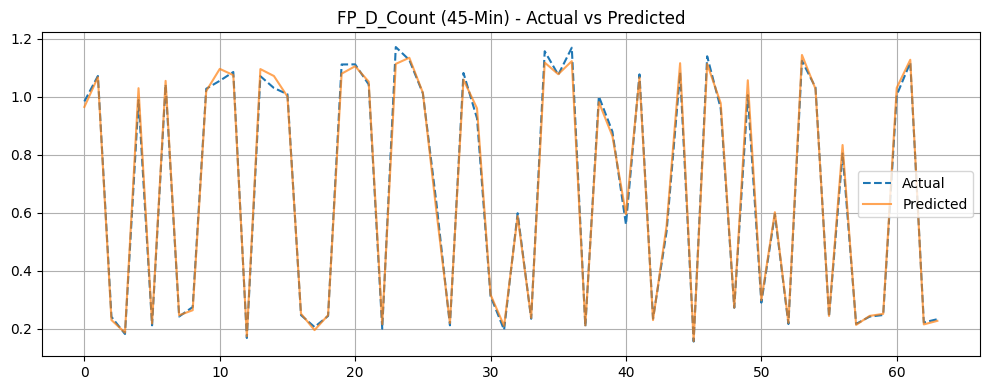

In [ ]:
#Tuning parameters, 400 trees, 25 depth, 45-minute interval.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# 45-minute downsampling
df_downsampled = df.groupby(np.arange(len(df)) // 2700).mean(numeric_only=True).reset_index(drop=True)

def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()
    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)
    lagged = lagged.dropna().reset_index(drop=True)
    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged["cosine_similarity"] = np.diag(cosine_similarity(lagged[lag_cols]))
    X = lagged.drop(columns=[target_col])
    y = lagged[target_col]
    return X, y

def run_rf(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=400, max_depth=25, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\n📊 45-Minute FP_D_Count Prediction:")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"R²: {r2_score(y_test, y_pred):.2f}")
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("FP_D_Count (45-Min) - Actual vs Predicted")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.show()

run_rf(df_downsampled, lag=2)



📊 10-Minute FP_D_Count Prediction:
MAE: 0.03
RMSE: 0.04
R²: 0.99


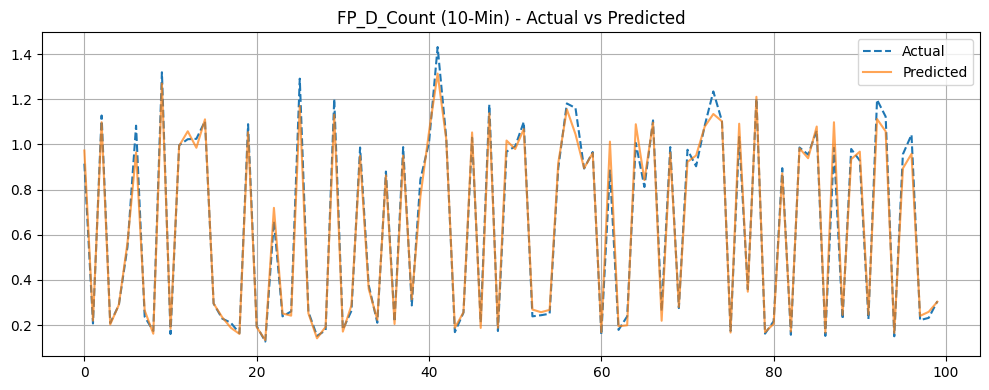

In [ ]:
#10-Minute Prediction (600 seconds), 200 trees, 15 depth.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# 10-minute downsampling
df_downsampled = df.groupby(np.arange(len(df)) // 600).mean(numeric_only=True).reset_index(drop=True)

def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()
    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)
    lagged = lagged.dropna().reset_index(drop=True)
    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged["cosine_similarity"] = np.diag(cosine_similarity(lagged[lag_cols]))
    X = lagged.drop(columns=[target_col])
    y = lagged[target_col]
    return X, y

def run_rf(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\n📊 10-Minute FP_D_Count Prediction:")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"R²: {r2_score(y_test, y_pred):.2f}")
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("FP_D_Count (10-Min) - Actual vs Predicted")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.show()

run_rf(df_downsampled, lag=2)



📊 20-Minute FP_D_Count Prediction:
MAE: 0.02
RMSE: 0.03
R²: 0.99


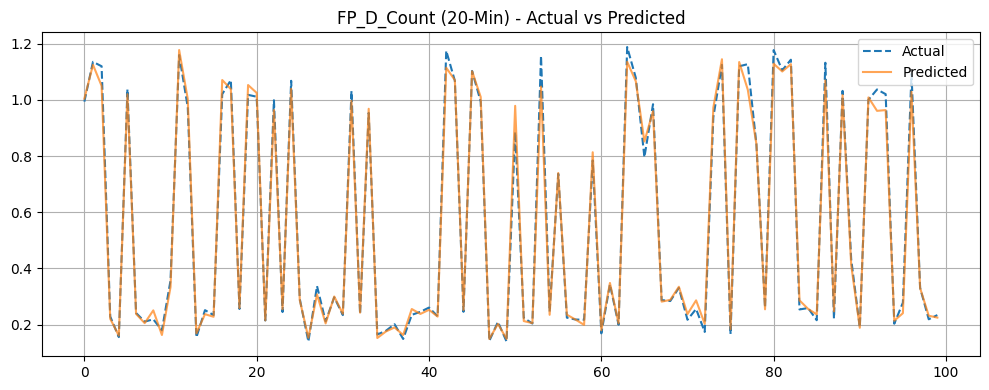

In [ ]:
#20-Minute Prediction (1200 seconds), 200 trees, 15 depth.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# 20-minute downsampling
df_downsampled = df.groupby(np.arange(len(df)) // 1200).mean(numeric_only=True).reset_index(drop=True)

def create_lagged_features_with_cosine(data, target_col="FP_D_Count", lag=2):
    relevant_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    lagged = data[relevant_cols].copy()
    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)
    lagged = lagged.dropna().reset_index(drop=True)
    lag_cols = [col for col in lagged.columns if '_lag' in col]
    lagged["cosine_similarity"] = np.diag(cosine_similarity(lagged[lag_cols]))
    X = lagged.drop(columns=[target_col])
    y = lagged[target_col]
    return X, y

def run_rf(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_features_with_cosine(data, target_col=target_col, lag=lag)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\n📊 20-Minute FP_D_Count Prediction:")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"R²: {r2_score(y_test, y_pred):.2f}")
    plt.figure(figsize=(10, 4))
    plt.plot(np.array(y_test[:100]), label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("FP_D_Count (20-Min) - Actual vs Predicted")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.show()

run_rf(df_downsampled, lag=2)
